# Phase 9 & 10: Cluster Profiling and Visualization
In this notebook, we attach the AI-generated cluster labels back to the original human-readable dataset. We will calculate the behavioral profiles of each cluster, prove their business value, and visualize them using PCA and Radar Charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import joblib
import os
from math import pi

sns.set_theme(style="whitegrid")

In [2]:
# 1. Load the raw data
df = pd.read_csv('../data/raw/bank-full.csv', sep=',')
target_features = ['age', 'balance', 'duration', 'campaign', 'previous']

# 2. Re-apply caps to generate the scaled matrix for prediction
df_capped = df.copy()
limits = {
    'balance': (df['balance'].quantile(0.01), df['balance'].quantile(0.99)),
    'duration': (df['duration'].min(), df['duration'].quantile(0.99)),
    'campaign': (df['campaign'].min(), df['campaign'].quantile(0.99)),
    'previous': (df['previous'].min(), df['previous'].quantile(0.99))
}
for col, (lower, upper) in limits.items():
    df_capped[col] = np.clip(df_capped[col], lower, upper)
X = df_capped[target_features]

# 3. Load Model and Scaler
scaler = joblib.load('../models/scaler.pkl')
kmeans = joblib.load('../models/kmeans_model.pkl')

# 4. Generate cluster labels
X_scaled = scaler.transform(X)
df['Cluster'] = kmeans.predict(X_scaled)

print("Cluster labels successfully attached to the raw dataset!")

Cluster labels successfully attached to the raw dataset!


## 1. Cluster Size Distribution
How many customers fall into each segment?

Customers per cluster:
Cluster
0     7757
1    34248
2     3206
Name: count, dtype: int64


C:\Users\Zain\AppData\Local\Temp\ipykernel_9872\247543332.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Cluster', palette='viridis')


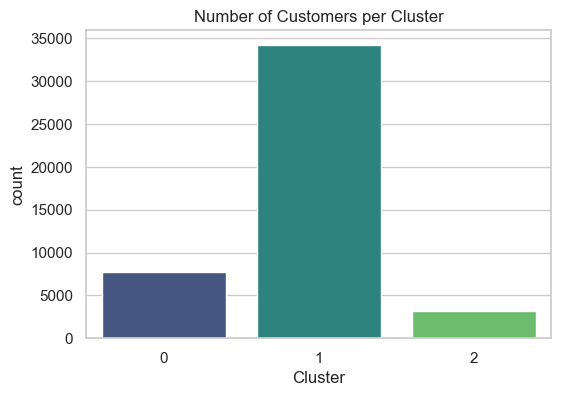

In [3]:
cluster_counts = df['Cluster'].value_counts().sort_index()
print("Customers per cluster:")
print(cluster_counts)

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Cluster', palette='viridis')
plt.title('Number of Customers per Cluster')
plt.show()

## 2. Cluster Profiling (The Business Personas)
Calculating the **average (mean)** behavior of the customers in each cluster using the *original, unscaled* data so the numbers are human-readable.

In [4]:
profile_mean = df.groupby('Cluster')[target_features].mean().round(2)
display(profile_mean)

# Save the profile table for the thesis
os.makedirs('../outputs', exist_ok=True)
profile_mean.to_csv('../outputs/cluster_profiles.csv')
print("Profile saved to outputs/cluster_profiles.csv")

,age,balance,duration,campaign,previous
Cluster,,,,,
0,43.53,4352.06,592.82,2.42,0.25
1,40.33,689.80,183.79,2.88,0.16
2,41.11,1312.06,242.92,2.34,5.83


Profile saved to outputs/cluster_profiles.csv


## 3. Business Validation (The 'y' Target Variable)
We did not let the AI see the `y` column (whether they subscribed to the deposit) during training. Now, let's look at the subscription rate per cluster to see if our behavioral segments actually predict business revenue!

C:\Users\Zain\AppData\Local\Temp\ipykernel_9872\3536596308.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='magma')


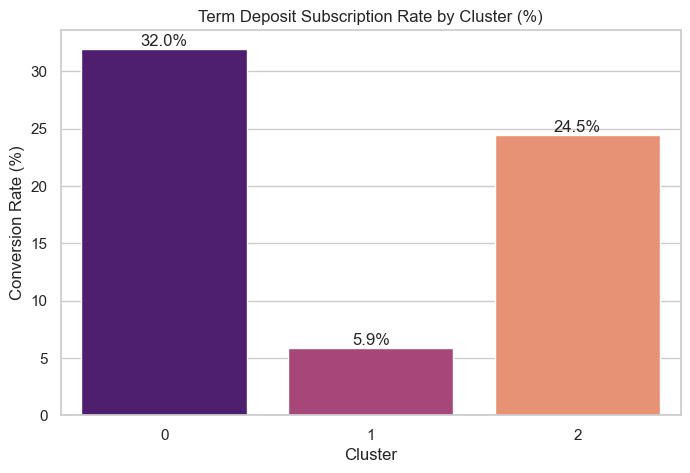

In [5]:
# Convert 'yes'/'no' to 1/0 for easy percentage calculation
df['y_numeric'] = df['y'].map({'yes': 1, 'no': 0})
conversion_rates = df.groupby('Cluster')['y_numeric'].mean() * 100

plt.figure(figsize=(8,5))
ax = sns.barplot(x=conversion_rates.index, y=conversion_rates.values, palette='magma')
plt.title('Term Deposit Subscription Rate by Cluster (%)')
plt.ylabel('Conversion Rate (%)')
plt.xlabel('Cluster')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='bottom')
plt.savefig('../figures/conversion_rate_by_cluster.png', bbox_inches='tight')
plt.show()

## 4. PCA Scatter Plot (Visual Proof)
Since our clusters exist in 5 dimensions, we use Principal Component Analysis (PCA) to compress them down to 2 dimensions so we can plot them on a 2D graph for your thesis defense.

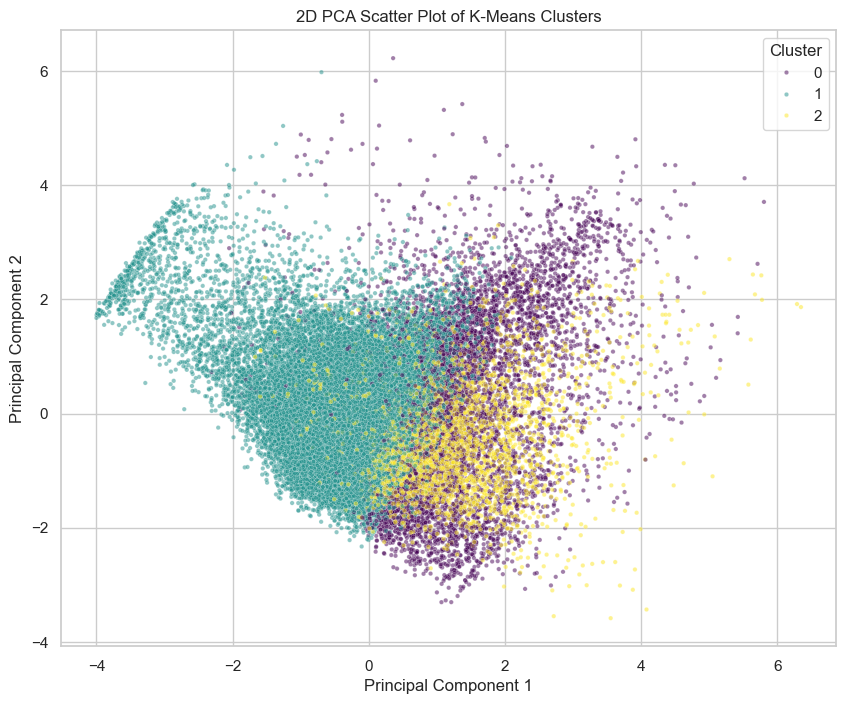

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['Cluster'] = df['Cluster']

plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=df_pca, palette='viridis', s=10, alpha=0.5)
plt.title('2D PCA Scatter Plot of K-Means Clusters')
plt.savefig('../figures/pca_scatter_plot.png', bbox_inches='tight')
plt.show()

## 5. Radar Chart (Spider Plot)
A radar chart provides a fantastic visual comparison of the cluster personas.

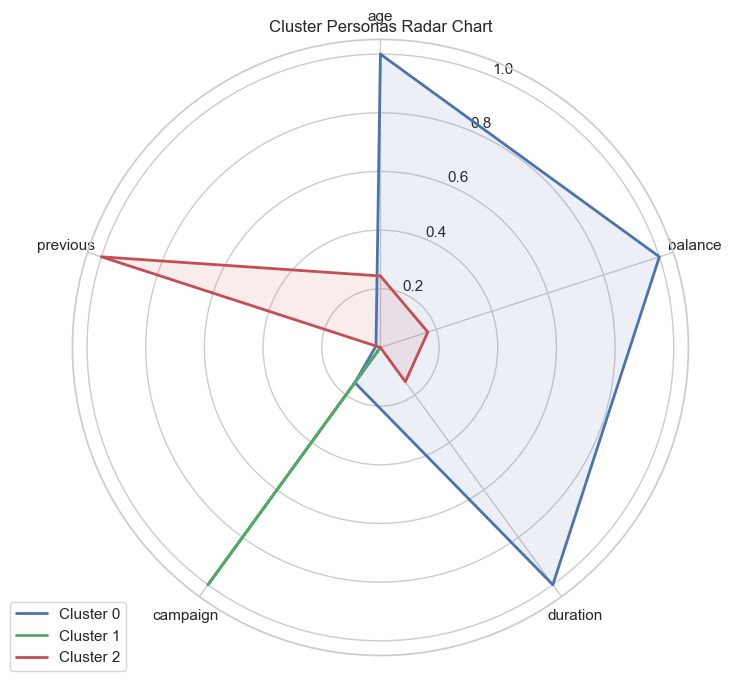

In [7]:
# Normalize the cluster means between 0 and 1 so they fit on the same radar chart
scaler_minmax = MinMaxScaler()
profile_scaled = pd.DataFrame(scaler_minmax.fit_transform(profile_mean), columns=profile_mean.columns)
profile_scaled['Cluster'] = profile_mean.index

# Radar chart setup
categories = target_features
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
plt.xticks(angles[:-1], categories)

colors = ['b', 'g', 'r', 'c', 'm']
for i, row in profile_scaled.iterrows():
    values = row[categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f"Cluster {int(row['Cluster'])}", color=colors[i])
    ax.fill(angles, values, colors[i], alpha=0.1)

plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
plt.title('Cluster Personas Radar Chart')
plt.savefig('../figures/cluster_radar_chart.png', bbox_inches='tight')
plt.show()

## 6. Save Final Dataset
We save the final dataset with the new 'Cluster' column attached. This file will be used by the Frontend Application.

In [8]:
df.drop(columns=['y_numeric'], inplace=True) # remove the temp numeric column
final_path = '../data/processed/clustered_customers.csv'
df.to_csv(final_path, index=False)
print(f"SUCCESS: Final dataset with AI clusters saved to {final_path}")

SUCCESS: Final dataset with AI clusters saved to ../data/processed/clustered_customers.csv
